## Calculus

#### Derivatives

A derivative measures how much the output changes when you nudge the input slightly.

In ML, x is a weight and f(x) is your loss. The derivative tells you: "if I increase this weight slightly, does the loss go up or down?"


#### Gradient

A derivative is for one variable. A gradient is for many variables — it's a vector of all partial derivatives.

The gradient points in the direction of steepest increase of loss. So you go the opposite direction — that's gradient descent.

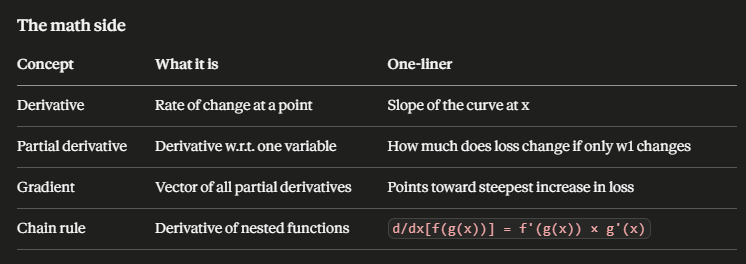

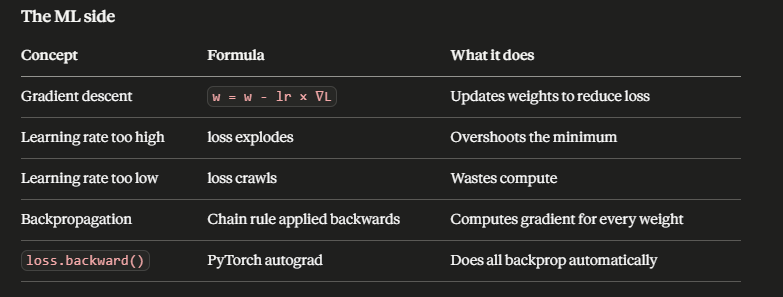

### Gradient Descent

In [1]:
# The entire learning algorithm, from scratch
weight = 5.0          # random starting point
lr     = 0.1          # learning rate — step size

def loss(w):           return (w - 2)**2 + 1   # minimum at w=2
def gradient(w):       return 2*(w - 2)         # derivative of loss

for step in range(20):
    grad = gradient(weight)
    weight = weight - lr * grad      # move opposite to gradient
    print(f"Step {step+1}: w={weight:.4f}, loss={loss(weight):.4f}")

# Step 1:  w=4.4000, loss=5.9536
# Step 5:  w=2.6242, loss=1.3896
# Step 20: w=2.0068, loss=1.0000  ← nearly at minimum

Step 1: w=4.4000, loss=6.7600
Step 2: w=3.9200, loss=4.6864
Step 3: w=3.5360, loss=3.3593
Step 4: w=3.2288, loss=2.5099
Step 5: w=2.9830, loss=1.9664
Step 6: w=2.7864, loss=1.6185
Step 7: w=2.6291, loss=1.3958
Step 8: w=2.5033, loss=1.2533
Step 9: w=2.4027, loss=1.1621
Step 10: w=2.3221, loss=1.1038
Step 11: w=2.2577, loss=1.0664
Step 12: w=2.2062, loss=1.0425
Step 13: w=2.1649, loss=1.0272
Step 14: w=2.1319, loss=1.0174
Step 15: w=2.1056, loss=1.0111
Step 16: w=2.0844, loss=1.0071
Step 17: w=2.0676, loss=1.0046
Step 18: w=2.0540, loss=1.0029
Step 19: w=2.0432, loss=1.0019
Step 20: w=2.0346, loss=1.0012


### Optimizers

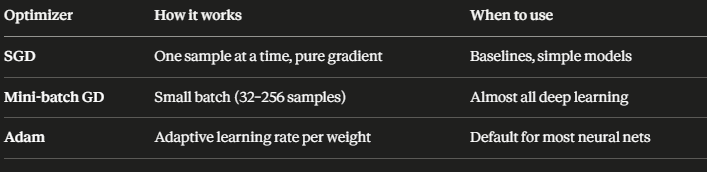

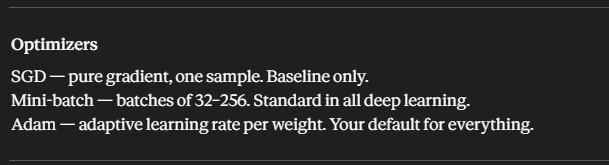

import torch, torch.nn as nn

model  = nn.Linear(3, 1)

optim  = torch.optim.Adam(model.parameters(), lr=0.001)

loss_fn= nn.MSELoss()

# One training step
pred = model(X)             # forward pass

loss = loss_fn(pred, y)     # compute loss

optim.zero_grad()           # clear old gradients

loss.backward()             # compute new gradients (chain rule)

optim.step()                # update weights (gradient descent)

#### Training Loop

pred = model(X)           # 1. forward pass

loss = loss_fn(pred, y)   # 2. compute error

optimizer.zero_grad()     # 3. clear old gradients

loss.backward()           # 4. backprop — chain rule

optimizer.step()          # 5. update weights

## Project - Gradient Descent from Scratch

In [2]:
import numpy as np

# Dataset: y = 3x + noise
np.random.seed(0)
X = np.random.randn(50)
y = 3*X + np.random.randn(50)*0.5

# Initialize weight and bias randomly
w, b = 0.0, 0.0
lr   = 0.05

for epoch in range(100):
    # Forward pass
    y_pred = w*X + b

    # Loss: Mean Squared Error
    loss = np.mean((y_pred - y)**2)

    # Gradients (derivatives of MSE w.r.t. w and b)
    dw = np.mean(2*(y_pred - y)*X)
    db = np.mean(2*(y_pred - y))

    # Update weights
    w -= lr * dw
    b -= lr * db

    if epoch % 20 == 0:
        print(f"Epoch {epoch}: loss={loss:.4f}, w={w:.3f}, b={b:.3f}")

print(f"\nLearned: y = {w:.2f}x + {b:.2f}")
print(f"Truth:   y = 3.00x + 0.00")

# Epoch 0:  loss=4.73, w=0.289, b=0.020
# Epoch 20: loss=0.37, w=2.741, b=0.025
# Epoch 80: loss=0.25, w=2.987, b=0.018
# Learned:  y = 2.99x + 0.02  ← almost exactly right

Epoch 0: loss=11.5850, w=0.383, b=0.041
Epoch 20: loss=0.2420, w=2.801, b=0.074
Epoch 40: loss=0.1878, w=2.963, b=0.008
Epoch 60: loss=0.1873, w=2.976, b=-0.005
Epoch 80: loss=0.1873, w=2.977, b=-0.007

Learned: y = 2.98x + -0.01
Truth:   y = 3.00x + 0.00
